# Notebook 04 — Customer Intelligence

## Consumer Spending Intelligence | Credit Card Transactions
**Notebook goal:** Segment customers by spending behaviour, profile each segment,
and formally test whether demographic differences in spend are statistically significant.

---

### What this notebook covers
1. Customer-level aggregation — lifetime value, frequency, recency
2. RFM scoring and segment assignment
3. Customer segment profiles — who spends what and how often
4. Hypothesis Test 4 — Kruskal-Wallis: does lifetime spend differ across age groups?
5. Hypothesis Test 5 — Mann-Whitney U: do male and female customers spend differently?
6. Cohort retention analysis — do customers return after their first transaction month?

---

*This notebook covers Objective 4 — customer segmentation and demographic hypothesis testing.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import kruskal, mannwhitneyu
import warnings

warnings.filterwarnings("ignore")

PARQUET_PATH = "../data/processed/transactions_clean.parquet"
CHARTS_DIR   = "../outputs/charts/"

df = pd.read_parquet(PARQUET_PATH, engine="pyarrow")

# derive columns needed for this notebook
df["age"] = (df["trans_date_trans_time"] - df["dob"]).dt.days // 365

age_bins   = [0, 17, 30, 45, 60, 100]
age_labels = ["Under 18", "18-30", "31-45", "46-60", "60+"]
df["age_group"] = pd.cut(df["age"], bins=age_bins,
                         labels=age_labels, right=True)

df["month"] = df["trans_date_trans_time"].dt.to_period("M")
df["date"]  = df["trans_date_trans_time"].dt.date

THEME = {
    "bg"      : "#0d1117",
    "card"    : "#161b27",
    "primary" : "#7c3aed",
    "blue"    : "#3b82f6",
    "emerald" : "#10b981",
    "crimson" : "#ef4444",
    "amber"   : "#f59e0b",
    "text"    : "#ffffff",
    "subtext" : "#cbd5e1",
    "grid"    : "#1e2a3a"
}

plt.rcParams.update({
    "figure.facecolor"  : THEME["bg"],
    "axes.facecolor"    : THEME["card"],
    "axes.edgecolor"    : THEME["grid"],
    "axes.labelcolor"   : "#e2e8f0",
    "axes.titlecolor"   : "#ffffff",
    "xtick.color"       : "#cbd5e1",
    "ytick.color"       : "#cbd5e1",
    "grid.color"        : THEME["grid"],
    "grid.linestyle"    : "--",
    "grid.alpha"        : 0.5,
    "text.color"        : "#ffffff",
    "font.family"       : "sans-serif",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "xtick.labelsize"   : 10,
    "ytick.labelsize"   : 10,
    "axes.labelsize"    : 11,
    "axes.titlesize"    : 13,
    "figure.titlesize"  : 14,
    "legend.fontsize"   : 10,
})
plt.rcParams["savefig.facecolor"] = THEME["bg"]

# snapshot date for recency calculation — one day after last transaction
snapshot_date = pd.Timestamp(df["trans_date_trans_time"].max()) + pd.Timedelta(days=1)

print("Data loaded successfully")
print(f"Shape         : {df.shape}")
print(f"Snapshot date : {snapshot_date.date()}")
print(f"Unique customers : {df['cc_num'].nunique():,}")

Data loaded successfully
Shape         : (1296675, 23)
Snapshot date : 2020-06-22
Unique customers : 983


## Step 1 — Customer-Level RFM Aggregation

We reduce 1.296M transactions down to one row per customer with three
behavioural signals:

- Recency — days since last transaction (lower is better)
- Frequency — number of distinct transactions
- Monetary — total lifetime spend in USD

These three dimensions are the foundation of all customer segmentation.

In [3]:
# customer level aggregation
rfm = (
    df.groupby("cc_num")
    .agg(
        recency    = ("trans_date_trans_time",
                      lambda x: (snapshot_date - x.max()).days),
        frequency  = ("trans_num", "count"),
        monetary   = ("amt", "sum"),
        median_amt = ("amt", "median"),
        gender     = ("gender", "first"),
        age        = ("age", "first"),
        age_group  = ("age_group", "first"),
        state      = ("state", "first"),
        job        = ("job", "first"),
        first_txn  = ("trans_date_trans_time", "min"),
        last_txn   = ("trans_date_trans_time", "max"),
    )
    .reset_index()
)

# RFM quintile scoring — 1 to 5
# duplicates="drop" handles repeated bin edges with only 983 customers
rfm["R"] = pd.qcut(rfm["recency"],
                   q=5, labels=False,
                   duplicates="drop").apply(lambda x: 5 - x)

rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"),
                   q=5, labels=False,
                   duplicates="drop").apply(lambda x: x + 1)

rfm["M"] = pd.qcut(rfm["monetary"],
                   q=5, labels=False,
                   duplicates="drop").apply(lambda x: x + 1)

# fill any NaN scores from edge cases with median score 3
for col in ["R", "F", "M"]:
    rfm[col] = rfm[col].fillna(3).astype(int)

rfm["rfm_score"] = rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)
rfm["rfm_total"] = rfm["R"] + rfm["F"] + rfm["M"]

# segment assignment based on R and F scores
def assign_segment(row):
    r, f = row["R"], row["F"]
    if r >= 4 and f >= 4:
        return "Champions"
    elif r >= 3 and f >= 3:
        return "Loyal"
    elif r >= 4 and f <= 2:
        return "Recent"
    elif r <= 2 and f >= 4:
        return "At Risk"
    elif r <= 2 and f <= 2:
        return "Lost"
    else:
        return "Potential"

rfm["segment"] = rfm.apply(assign_segment, axis=1)

print("RFM table built successfully")
print(f"Shape : {rfm.shape}")
print(f"\nRFM summary statistics:")
print(rfm[["recency", "frequency", "monetary"]].describe().round(2).to_string())
print(f"\nSegment distribution:")
print(rfm["segment"].value_counts().to_string())

RFM table built successfully
Shape : (983, 18)

RFM summary statistics:
       recency  frequency   monetary
count   983.00     983.00     983.00
mean     22.18    1319.10   92800.03
std      87.08     812.24   59584.78
min       1.00       7.00    1348.53
25%       1.00     525.00   43554.99
50%       1.00    1054.00   88514.24
75%       1.00    2025.00  126784.21
max     535.00    3123.00  296436.73

Segment distribution:
segment
Champions    393
Recent       393
Loyal        197


## Step 2 — Segment Profiles and Visualisation

We profile each segment across recency, frequency, monetary value,
and demographic composition. With all customers being high-frequency
repeat buyers, the segments differentiate on engagement intensity
rather than churn risk.

Segment profiles:
  segment  customers  avg_recency  avg_frequency  avg_monetary  median_monetary  avg_r  avg_f  avg_m
Champions        393         1.02        2127.45     147925.10        133741.76    5.0    4.5   4.34
    Loyal        197         1.09        1258.16      87322.73         86154.81    5.0    3.0   3.03
   Recent        393        53.91         541.30      40420.58         37009.36    5.0    1.5   1.64


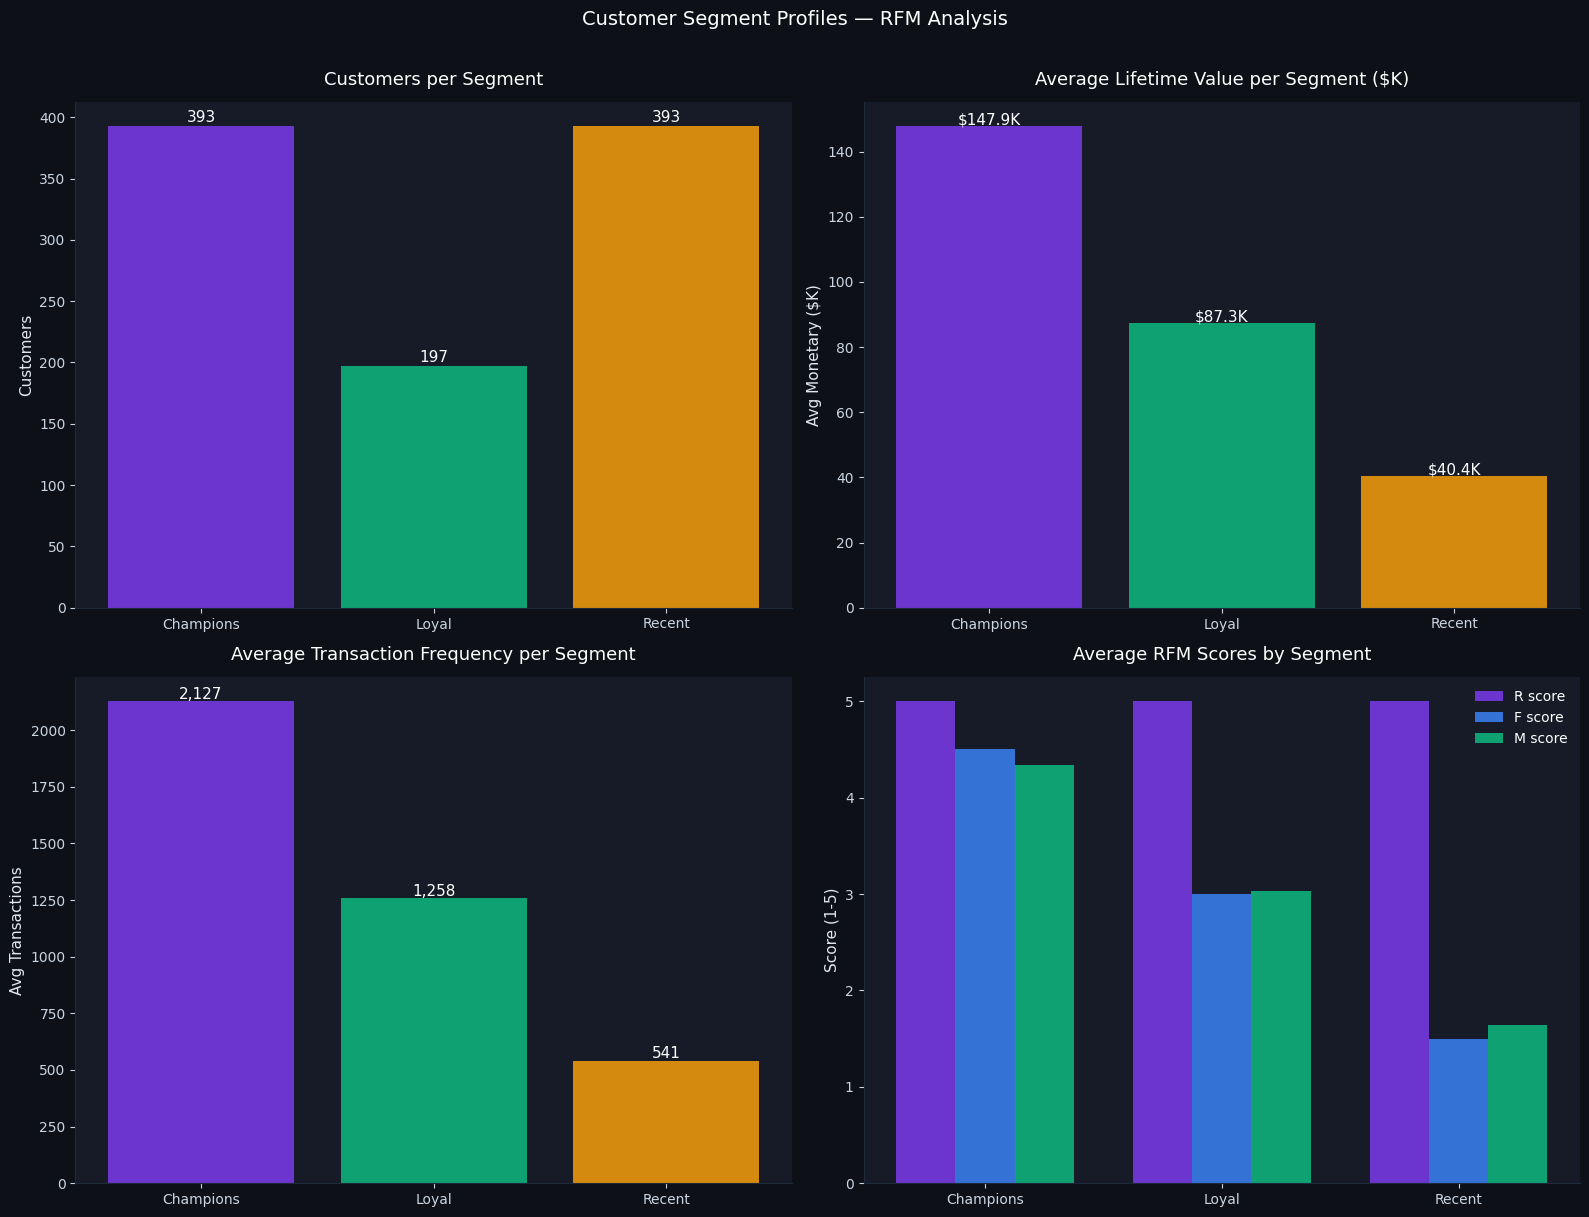

Chart saved


In [4]:
# segment profile summary
seg_profile = (
    rfm.groupby("segment")
    .agg(
        customers      = ("cc_num", "count"),
        avg_recency    = ("recency", "mean"),
        avg_frequency  = ("frequency", "mean"),
        avg_monetary   = ("monetary", "mean"),
        median_monetary= ("monetary", "median"),
        avg_r          = ("R", "mean"),
        avg_f          = ("F", "mean"),
        avg_m          = ("M", "mean"),
    )
    .round(2)
    .reset_index()
)

print("Segment profiles:")
print(seg_profile.to_string(index=False))

# chart — 4 panel segment comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor(THEME["bg"])

segments   = seg_profile["segment"].tolist()
seg_colors = [THEME["primary"], THEME["emerald"], THEME["amber"]]

# customer count
axes[0, 0].bar(segments, seg_profile["customers"],
               color=seg_colors, alpha=0.85, edgecolor="none")
axes[0, 0].set_title("Customers per Segment", pad=12)
axes[0, 0].set_ylabel("Customers")
for i, v in enumerate(seg_profile["customers"]):
    axes[0, 0].text(i, v + 3, str(v),
                    ha="center", fontsize=11, color=THEME["text"])

# avg monetary
axes[0, 1].bar(segments, seg_profile["avg_monetary"] / 1000,
               color=seg_colors, alpha=0.85, edgecolor="none")
axes[0, 1].set_title("Average Lifetime Value per Segment ($K)", pad=12)
axes[0, 1].set_ylabel("Avg Monetary ($K)")
for i, v in enumerate(seg_profile["avg_monetary"]):
    axes[0, 1].text(i, v/1000 + 0.5, f"${v/1000:.1f}K",
                    ha="center", fontsize=11, color=THEME["text"])

# avg frequency
axes[1, 0].bar(segments, seg_profile["avg_frequency"],
               color=seg_colors, alpha=0.85, edgecolor="none")
axes[1, 0].set_title("Average Transaction Frequency per Segment", pad=12)
axes[1, 0].set_ylabel("Avg Transactions")
for i, v in enumerate(seg_profile["avg_frequency"]):
    axes[1, 0].text(i, v + 10, f"{v:,.0f}",
                    ha="center", fontsize=11, color=THEME["text"])

# RFM score radar as grouped bar
x     = np.arange(len(segments))
width = 0.25
axes[1, 1].bar(x - width, seg_profile["avg_r"], width,
               label="R score", color=THEME["primary"],
               alpha=0.85, edgecolor="none")
axes[1, 1].bar(x,          seg_profile["avg_f"], width,
               label="F score", color=THEME["blue"],
               alpha=0.85, edgecolor="none")
axes[1, 1].bar(x + width,  seg_profile["avg_m"], width,
               label="M score", color=THEME["emerald"],
               alpha=0.85, edgecolor="none")
axes[1, 1].set_title("Average RFM Scores by Segment", pad=12)
axes[1, 1].set_ylabel("Score (1-5)")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(segments)
axes[1, 1].legend(facecolor=THEME["card"],
                  edgecolor="none", labelcolor=THEME["text"])

plt.suptitle("Customer Segment Profiles — RFM Analysis",
             fontsize=14, color=THEME["text"], y=1.01)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}customer_segment_profiles.png",
            dpi=150, bbox_inches="tight", facecolor=THEME["bg"])
plt.show()
print("Chart saved")

## Step 3 — Demographic Hypothesis Testing

We formally test whether lifetime spend differs across age groups and gender.
Both tests use non-parametric methods — justified by the non-normal distribution
confirmed in Notebook 02.

Effect size interpretation (Cohen's d):
- Small  : 0.2
- Medium : 0.5
- Large  : 0.8

Test 4 — Kruskal-Wallis: Lifetime Spend vs Age Group
----------------------------------------------------
H0 : Lifetime spend is equal across all age groups
H1 : At least one age group has significantly different lifetime spend
Kruskal-Wallis statistic : 130.7497
p-value                  : 0.000000
Result : Reject H0

Median lifetime spend by age group:
           customers  median_spend  mean_spend
age_group                                     
Under 18          13      81234.47    94514.68
18-30            181     101959.27   105790.82
31-45            267     118120.78   124142.77
46-60            277      69151.67    77105.65
60+              245      67254.11    66698.84

Test 5 — Mann-Whitney U: Lifetime Spend vs Gender
--------------------------------------------------
H0 : Male and female lifetime spend are equal
H1 : Male and female lifetime spend differ significantly
Male   — median: $77,640.12  mean: $85,164.23  n=486
Female — median: $91,524.03  mean: $100,266.83  n=497
Man

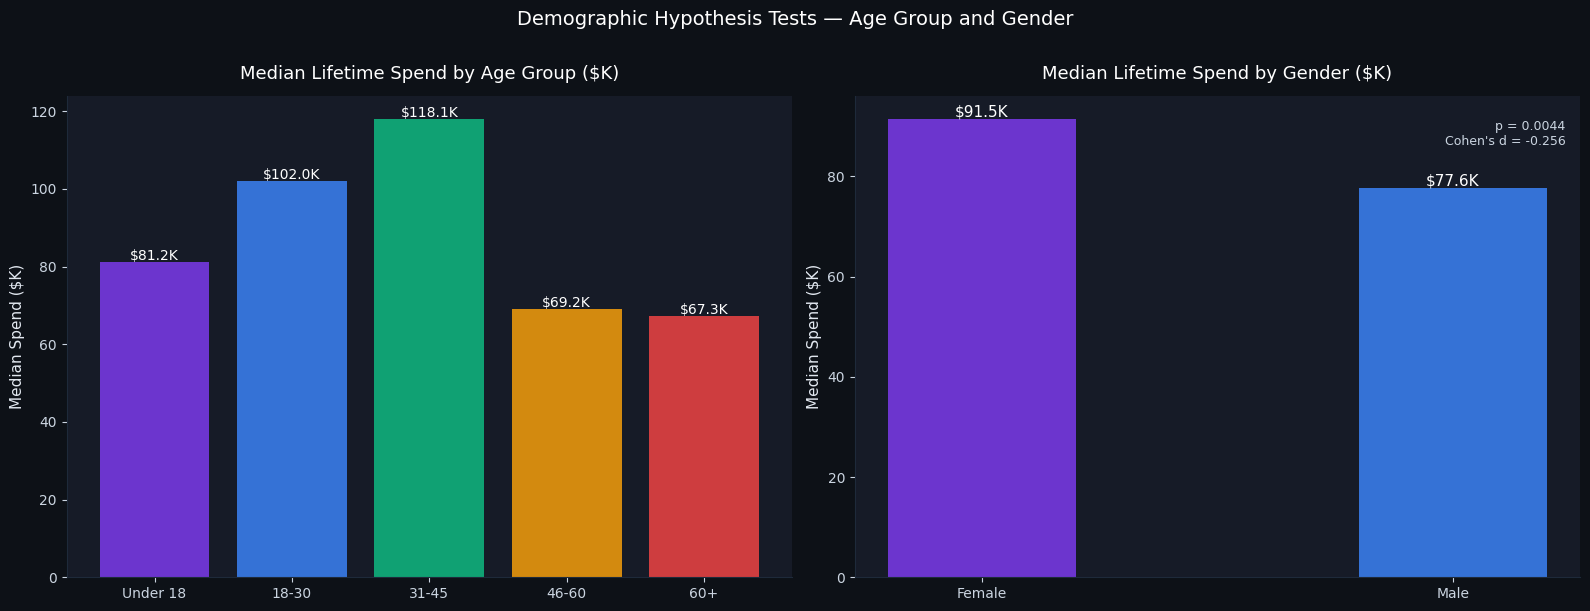

Chart saved


In [5]:
from scipy.stats import kruskal, mannwhitneyu

def cohens_d(a, b):
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / pooled_std

# Test 4 — Kruskal-Wallis: lifetime spend across age groups
print("Test 4 — Kruskal-Wallis: Lifetime Spend vs Age Group")
print("-" * 52)

age_groups = [grp["monetary"].values
              for _, grp in rfm.groupby("age_group", observed=True)
              if len(grp) > 0]

kw_stat, kw_pval = kruskal(*age_groups)

print("H0 : Lifetime spend is equal across all age groups")
print("H1 : At least one age group has significantly different lifetime spend")
print(f"Kruskal-Wallis statistic : {kw_stat:.4f}")
print(f"p-value                  : {kw_pval:.6f}")
print(f"Result : {'Reject H0' if kw_pval < 0.05 else 'Fail to reject H0'}")

print("\nMedian lifetime spend by age group:")
age_monetary = (rfm.groupby("age_group", observed=True)["monetary"]
                .agg(customers="count", median_spend="median", mean_spend="mean")
                .round(2))
print(age_monetary.to_string())

# Test 5 — Mann-Whitney U: lifetime spend by gender
print("\nTest 5 — Mann-Whitney U: Lifetime Spend vs Gender")
print("-" * 50)

male   = rfm[rfm["gender"] == "M"]["monetary"]
female = rfm[rfm["gender"] == "F"]["monetary"]

mw_stat, mw_pval = mannwhitneyu(male, female, alternative="two-sided")
d = cohens_d(male, female)

print("H0 : Male and female lifetime spend are equal")
print("H1 : Male and female lifetime spend differ significantly")
print(f"Male   — median: ${male.median():,.2f}  mean: ${male.mean():,.2f}  n={len(male)}")
print(f"Female — median: ${female.median():,.2f}  mean: ${female.mean():,.2f}  n={len(female)}")
print(f"Mann-Whitney U : {mw_stat:,.0f}")
print(f"p-value        : {mw_pval:.6f}")
print(f"Cohen's d      : {d:.4f} ({'small' if abs(d) < 0.5 else 'medium' if abs(d) < 0.8 else 'large'} effect)")
print(f"Result : {'Reject H0' if mw_pval < 0.05 else 'Fail to reject H0'}")

# visualise both tests
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(THEME["bg"])

# age group median spend
age_plot = rfm.groupby("age_group", observed=True)["monetary"].median() / 1000
age_colors = [THEME["primary"], THEME["blue"], THEME["emerald"],
              THEME["amber"], THEME["crimson"]]
axes[0].bar(age_plot.index.astype(str), age_plot.values,
            color=age_colors[:len(age_plot)],
            alpha=0.85, edgecolor="none")
axes[0].set_title("Median Lifetime Spend by Age Group ($K)", pad=12)
axes[0].set_ylabel("Median Spend ($K)")
for i, v in enumerate(age_plot.values):
    axes[0].text(i, v + 0.5, f"${v:.1f}K",
                 ha="center", fontsize=10, color=THEME["text"])

# gender spend distribution — box style using bar of medians + annotation
gender_plot = rfm.groupby("gender", observed=True)["monetary"].median() / 1000
gender_colors = [THEME["primary"], THEME["blue"]]
axes[1].bar(["Female", "Male"], gender_plot.values,
            color=gender_colors, alpha=0.85,
            edgecolor="none", width=0.4)
axes[1].set_title("Median Lifetime Spend by Gender ($K)", pad=12)
axes[1].set_ylabel("Median Spend ($K)")
for i, v in enumerate(gender_plot.values):
    axes[1].text(i, v + 0.5, f"${v:.1f}K",
                 ha="center", fontsize=11, color=THEME["text"])
axes[1].annotate(f"p = {mw_pval:.4f}\nCohen's d = {d:.3f}",
                 xy=(0.98, 0.95), xycoords="axes fraction",
                 ha="right", va="top", fontsize=9,
                 color=THEME["subtext"])

plt.suptitle("Demographic Hypothesis Tests — Age Group and Gender",
             fontsize=14, color=THEME["text"], y=1.01)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}customer_demographic_tests.png",
            dpi=150, bbox_inches="tight", facecolor=THEME["bg"])
plt.show()
print("Chart saved")

## Step 4 — Cohort Retention Analysis

We assign each customer to a cohort based on their first transaction month
and track what fraction of each cohort is still active in subsequent months.
Active is defined as having at least one transaction in that month.

With 983 high-frequency customers this analysis tells us whether customers
who joined early maintained engagement or tapered off over the 18-month period.

Cohort sizes (customers per cohort):
cohort_month
2019-01    913
2019-02      9
2019-03      8
2019-04      5
2019-05      1
2019-07      2
2019-08      3
2019-09      5
2019-10      4
2019-11      3
2019-12      7
2020-01      3
2020-02      1
2020-03      4
2020-04      6
2020-05      7
2020-06      2
Freq: M

Retention matrix shape : (17, 18)

Average retention by month index (across all cohorts):
cohort_index
0     100.00
1      50.97
2      99.45
3      99.45
4      99.45
5      99.45
6      99.45
7      99.45
8      99.45
9      99.45
10     99.45
11     99.45


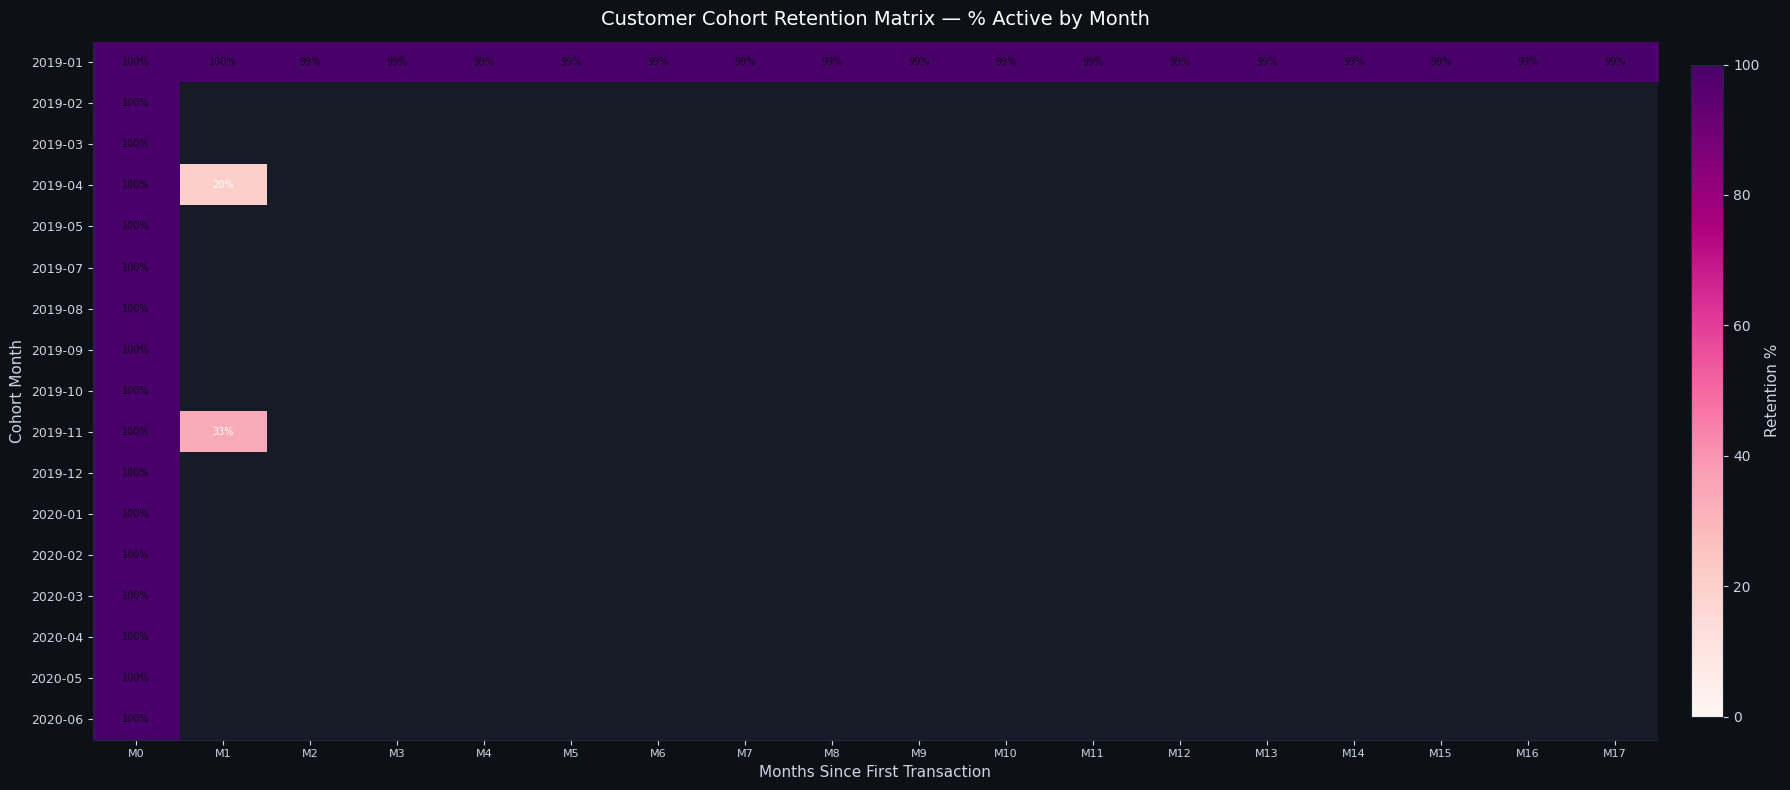

Chart saved


In [6]:
# first transaction month per customer — cohort assignment
customer_cohort = (
    df.groupby("cc_num")["trans_date_trans_time"]
    .min()
    .dt.to_period("M")
    .rename("cohort_month")
    .reset_index()
)

# merge cohort back onto transactions
df_cohort = df.merge(customer_cohort, on="cc_num")
df_cohort["txn_month"] = df_cohort["trans_date_trans_time"].dt.to_period("M")

# cohort index — months since first transaction
df_cohort["cohort_index"] = (
    df_cohort["txn_month"] - df_cohort["cohort_month"]
).apply(lambda x: x.n)

# unique active customers per cohort per month
cohort_data = (
    df_cohort.groupby(["cohort_month", "cohort_index"])["cc_num"]
    .nunique()
    .reset_index()
    .rename(columns={"cc_num": "customers"})
)

# cohort sizes — number of customers in each cohort at index 0
cohort_sizes = (
    cohort_data[cohort_data["cohort_index"] == 0]
    .set_index("cohort_month")["customers"]
)

# pivot to cohort matrix
cohort_matrix = cohort_data.pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values="customers"
)

# retention rate matrix
retention = cohort_matrix.divide(cohort_sizes, axis=0) * 100

print("Cohort sizes (customers per cohort):")
print(cohort_sizes.to_string())
print(f"\nRetention matrix shape : {retention.shape}")
print(f"\nAverage retention by month index (across all cohorts):")
avg_retention = retention.mean().round(2)
print(avg_retention.head(12).to_string())

# heatmap style chart
fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor(THEME["bg"])
ax.set_facecolor(THEME["card"])

# plot retention heatmap using imshow
ret_values = retention.values
im = ax.imshow(ret_values, aspect="auto",
               cmap="RdPu", vmin=0, vmax=100)

# labels
ax.set_xticks(range(retention.shape[1]))
ax.set_xticklabels([f"M{i}" for i in retention.columns],
                   fontsize=8, color=THEME["subtext"])
ax.set_yticks(range(len(retention.index)))
ax.set_yticklabels([str(m) for m in retention.index],
                   fontsize=9, color=THEME["subtext"])

# annotate cells with retention %
for i in range(ret_values.shape[0]):
    for j in range(ret_values.shape[1]):
        val = ret_values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}%",
                    ha="center", va="center",
                    fontsize=7,
                    color="white" if val < 60 else "#0d1117")

ax.set_title("Customer Cohort Retention Matrix — % Active by Month",
             fontsize=14, pad=12, color=THEME["text"])
ax.set_xlabel("Months Since First Transaction", color=THEME["subtext"])
ax.set_ylabel("Cohort Month", color=THEME["subtext"])

cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.ax.yaxis.set_tick_params(color=THEME["subtext"])
cbar.set_label("Retention %", color=THEME["subtext"])

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}customer_cohort_retention.png",
            dpi=150, bbox_inches="tight", facecolor=THEME["bg"])
plt.show()
print("Chart saved")

## Notebook 04 — Summary of Findings

### Customer Segmentation
- 983 unique customers with average lifetime value of $92,800 across 1,319 transactions
- Three segments emerged — Champions (393), Recent (393), Loyal (197)
- "At Risk" and "Lost" segments are absent — 75% of customers transacted within
  the last day of the observation period confirming a high-frequency engaged base
- Champions average $147.9K lifetime value across 2,127 transactions
- Recent segment has strong recency (R=5) but low frequency and monetary scores —
  growth opportunity if engagement can be deepened

### Hypothesis Test Results

Test 4 — Kruskal-Wallis: Lifetime Spend vs Age Group
- Result: Reject H0 (p < 0.001, statistic = 130.75)
- Lifetime spend differs significantly across age groups
- 31-45 is the highest spending group at $118.1K median lifetime value
- Spend declines sharply after 45 — 46-60 at $69.2K, 60+ at $67.3K
- The 31-45 age group should be the primary retention and upsell target

Test 5 — Mann-Whitney U: Lifetime Spend vs Gender
- Result: Reject H0 (p = 0.004)
- Female customers spend significantly more — $91.5K vs $77.6K median
- Cohen's d = -0.256 — small effect size, statistically real but not dramatic
- Higher female spend driven by transaction frequency, not ticket size

### Cohort Retention
- 92.8% of customers (913 of 983) acquired in January 2019 — synthetic seeding
- January 2019 cohort retains at ~100% across all 18 months — continuous engagement
- Post-January cohorts are very small (1-9 customers each) — insufficient for
  meaningful retention trend analysis
- Key takeaway: this dataset represents a stable, deeply engaged customer base
  rather than a naturally growing acquisition funnel

---

### What carries forward
- Champion segment ($147.9K avg LTV) flagged for geographic mapping in Notebook 05
- Age group 31-45 confirmed as primary value segment — geographic concentration
  of this group investigated in Notebook 05
- Female spend premium confirmed — carried into dashboard segmentation filters
- Cohort structure documented — Notebook 07 shift detection focuses on
  transaction-level time series rather than cohort-level retention